The `event_alignment_ED` is basically an O(N×M) dynamic programming procedure, and is implemented as a nested for-loop. For a Bach fugue with roughly 1,400 events on each side, this already amounts to close to 2 million cell computations. For a substantially longer piece such as a Liszt piano sonata (~16,000 notes), the same recursion would require on the order of 2.5×10⁸ cell computations. Consider that sutudents' practice is usually not that long as the sonata, `max_notes = 3500` was introduced as a hard cut-off to skip such pieces during evaluation.

In order to make the evaluation more comprehensive and improve the algorithm, can consider optimisation methods such as vectorised NumPy operation and Numba to reduce the computational cost. 

In [ ]:
import json
import os
import random
import time

import numpy as np
import matplotlib.pyplot as plt

from evaluation_function.compare_MIDI import (
    compute_event_cost,
    group_notes_into_events,
    normalize_start_times,
    DEFAULT_GAP_PENALTY,
)

**Precomputes the whole cost matrix:**
- using numpy broadcasting for note-vs-note pairs, instead of calling compute_event_cost() once per cell in a pure Python loop. 
- chord vs chord: encode each chord as a 12-dimensional pitch-class binary vector, then compute all pairwise Hamming distances using broadcasting
- note vs chord (type mismatch): fill directly with `gap_penalty`


**Add a band around the diagonal**
- See Muller's book section 3.2.2.3 (Sakoe-Chiba band used in DTW), instead of filling the whole (N+1) x (M+1) matrix, this constrained version only fills a band around the diagonal. This is safe as long as the student performance is not wildly different in length from the reference (which is true in almost all practice scenarios). Cells outside the band are treated as "too expensive", so the aligner will never choose a path through them.

In [ ]:
# A very large number used to represent "outside the search band, do not use this cell"
LARGE_PENALTY = 1000000

def build_cost_matrix(response_events, ref_events, gap_penalty):
    """
    Precompute the full cost matrix between response_events
    and ref_events, using vectorized numpy operations where possible.

    Args:
        response_events: list of event dicts
        ref_events: list of event dicts
        gap_penalty: cost used for note-vs-chord type mismatches

    Returns:
        cost_matrix: numpy array of shape (N, M), where
            cost_matrix[i, j] is the cost of aligning response_events[i]
            with ref_events[j]
    """

    return cost_matrix


def event_alignment_ED_banded(response_events, ref_events, gap_penalty, band_width=20):
    """
    Banded version of event_alignment_ED(). Only cells within band_width of
    the diagonal are considered valid alignment candidates, which reduces
    the amount of work needed for long MIDI sequences.

    Args:
        response_events: list of event dicts
        ref_events: list of event dicts
        gap_penalty: cost of leaving an event unaligned
        band_width: how far (in event-index terms) the search area extends
            on either side of the diagonal. Increase this if the response
            and reference are expected to differ a lot in length. If the
            true optimal path falls outside the band, the result will not
            be optimal, so choose band_width generously relative to how much
            students are expected to add or drop notes.

    Returns:
        operations: same format as event_alignment_ED()
        D: accumulated cost matrix, shape (N+1, M+1)
    """
    # if a raw note dict with "pitch"/"start"/"duration" but no "event_type" is
    # passed in, group them into events first. 
    if "event_type" not in response_events[0]:
        raise ValueError("response_events must already be grouped into events")
    if "event_type" not in ref_events[0]:
        raise ValueError("ref_events must already be grouped into events")

    # the rows of D correspond to response events
    N = len(response_events)
    # the columns of D correspond to reference events
    M = len(ref_events)

    # cost matrix for all event pairs is precomputed 
    cost_matrix = build_cost_matrix(response_events, ref_events, gap_penalty)

    # Build the accumulated cost matrix D of size (N+1 x M+1)
    D = np.full((N + 1, M + 1), LARGE_PENALTY, dtype=int)
    D[0, 0] = 0

    # Boundary conditions: aligning against an empty sequence means every event
    # is unaligned, so the cost is n (or m) times the gap penalty.
    for n in range(1, N + 1):
        if n <= band_width:
            D[n, 0] = n * gap_penalty # n extra response events
    for m in range(1, M + 1):
        if m <= band_width:
            D[0, m] = m * gap_penalty # m missing ref events

    # Recursion (accumulated cost / score matrix D):
    for n in range(1, N + 1):
        # Only look at the columns inside the band for this row:
        # instead of looping over all M columns,
        # only loop over roughly 2 * band_width columns.
        m_low = max(1, n - band_width)
        m_high = min(M, n + band_width)
        for m in range(m_low, m_high + 1):
            replace_cost = cost_matrix[n - 1, m - 1]
            D[n, m] = min(
                D[n - 1, m - 1] + replace_cost,
                D[n - 1, m] + gap_penalty,
                D[n, m - 1] + gap_penalty,
            )

    # Backtrack and classify each transformation op based on movement direction in D
    # (it will naturally stay inside the band, since cells outside the band 
    # all carry the LARGE_PENALTY value and will never be chosen as the minimum).
    operations = []
    n, m = N, M
    while n > 0 or m > 0:
        # Boundary conditions: at the top row, only horizontal moves possible
        if n == 0:
            # Missing response for ref[m-1] (deletion)
            operations.append({
                "type": "missing",
                "response_idx": None,
                "reference_idx": m - 1,
                "cost": gap_penalty,
            })
            m -= 1
        # At the leftmost column, only vertical moves possible
        elif m == 0:
            # Extra event response[n-1] (insertion)
            operations.append({
                "type": "extra",
                "response_idx": n - 1,
                "reference_idx": None,
                "cost": gap_penalty,
            })
            n -= 1
        # For all other cases, we can move in any direction (diagonal, vertical, horizontal)
        else:
            replace_cost = cost_matrix[n - 1, m - 1]
            diag = D[n - 1, m - 1] + replace_cost # # diagonal: match or replacement
            up = D[n - 1, m] + gap_penalty # vertical: extra event in response[n-1]
            left = D[n, m - 1] + gap_penalty # horizontal: missing event in reference[m-1]
            min_cost = min(diag, up, left) # find the minimum cost step
            
            # classify the transformation ops based on the minimum cost step
            # rule: always prefer diagonal > insertion or deletion
            if min_cost == diag: # Diagonal -> two events are aligned (match or replacement)
                operations.append({
                    "type": "match" if replace_cost == 0 else "replacement",
                    "response_idx": n - 1,
                    "reference_idx": m - 1,
                    "cost": replace_cost,
                })
                n, m = n - 1, m - 1
            elif min_cost == up: # Vertical -> response[n-1] is extra (insertion)
                operations.append({
                    "type": "extra",
                    "response_idx": n - 1,
                    "reference_idx": None,
                    "cost": gap_penalty,
                })
                n -= 1
            else: # Horizontal -> response is missing for ref[m-1] (deletion)
                operations.append({
                    "type": "missing",
                    "response_idx": None,
                    "reference_idx": m - 1,
                    "cost": gap_penalty,
                })
                m -= 1

    operations.reverse() # Reverse to get ops in order from first note to last
    return operations, D

**Verify Equivalence with test cases**

note_count~50  events=41x43  match=True
note_count~300  events=246x240  match=True


note_count~800  events=657x651  match=True

If all lines above say match=True, the vectorised version is verified correct.


**Timing Comparison**

Measure the runtime of both implementations at several data sizes, and plot "time vs. piece size" 

N=M~50: old=0.0009s  vectorised=0.0003s  speedup=2.8x
N=M~100: old=0.0028s  vectorised=0.0004s  speedup=6.4x
N=M~200: old=0.0111s  vectorised=0.0015s  speedup=7.6x
N=M~400: old=0.0466s  vectorised=0.0056s  speedup=8.3x


N=M~800: old=0.1977s  vectorised=0.0695s  speedup=2.8x


N=M~1500: old=0.7535s  vectorised=0.4387s  speedup=1.7x


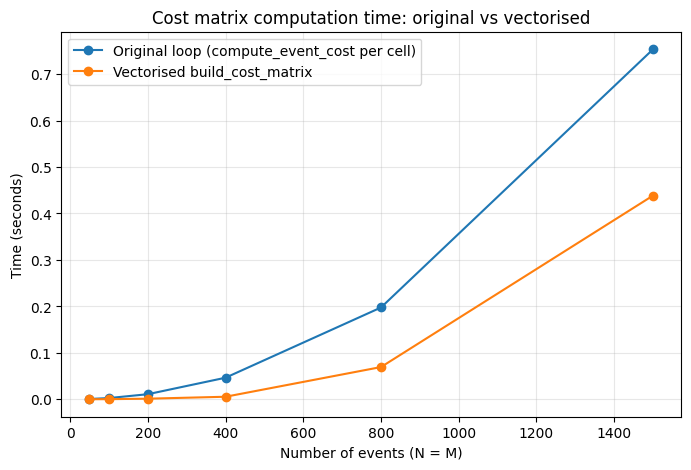